# Single Variable Calculus - A Review

This post will outline a general overview of single variable calculus as seen in my course notes for my two semester university program. Much of this will come from segments taken from the TA's writings, and I will add some computational evaluations of the answers as well.

In [56]:
import math
import numpy as np
import matplotlib.pyplot as plt

## MATH 140 - Pre-Midterm

### Part 1: Chapter 0 - Intro

A function, $y = f(x)$ takes values $x$ from the domain $D_f$ and outputs values $y$ from the range $R_f$. For each value $x \in D_f$, there is only one corresponding value of $y$.

__Examples__:

1) Consider $f(x) = 1 / x$. Then we have that $D_f = (-\inf; 0)\cup(0;+\inf) = \mathbb{R}\setminus\{0\}$. This means that for any $x \in D_f$ we can know the value of $f(x)$ simply by plugging in $x$ in the exponent of $1/x$. However, if we look at the graph of $f(x) = 1/x$, the four questions arise:
    * What happens when $x > 0$ gets closer and closer to 0? This is the idea behind taking the limit $\lim_{x \to 0^+} f(x)$.
    * What happens when $x < 0$ gets closer and closer to 0? This is the idea behind taking the limit $\lim_{x \to 0^-} f(x)$.
    * What happens when $x$ gets larger and larger, more precisely infinitely large. This brings us to study $\lim_{x \to +\inf} f(x)$.
    * What about when $x$ gets infinitely negatively big? This leads to $lim_{x \to -\inf} f(x)$.

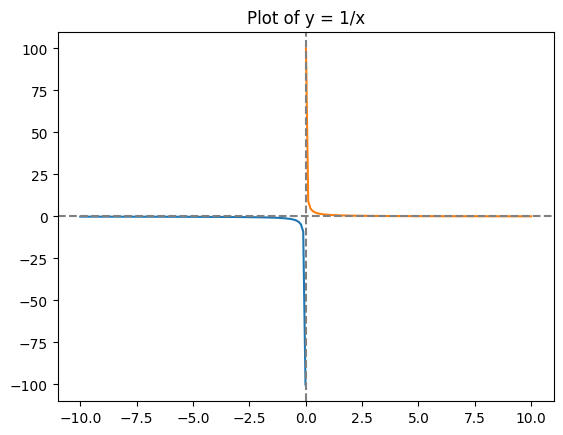

In [57]:
f = lambda x: 1/x

x = np.linspace(-10, -0.01, 100)
y = [f(xi) for xi in x]
plt.plot(x, y)

x = np.linspace(0.01, 10, 100)
y = [f(xi) for xi in x]
plt.plot(x, y)

plt.axvline(0, linestyle="--", color="grey")
plt.axhline(0, linestyle="--", color="grey")
plt.title("Plot of y = 1/x");

2) Another example is $f(x) = e^{1/x}/x^3$ that has domain $D_f = (-\inf;0)\cup(0;+\inf)$. We see that the exact same four questions arise when understanding what values of $y$ are in $R_f$.

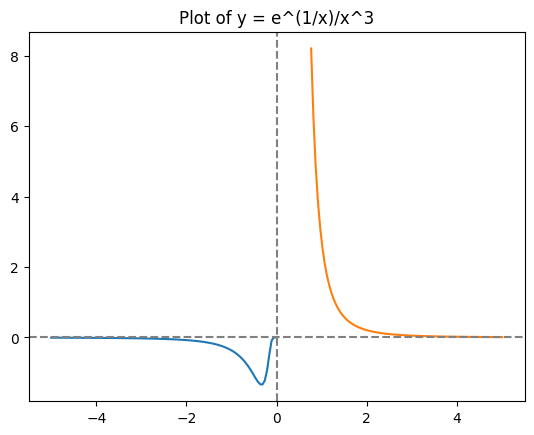

In [58]:
f = lambda x: (math.e**(1/x))/(x**3)

x = np.linspace(-5, -0.01, 100)
y = np.array([f(xi) for xi in x])
mask = [yi < 10 for yi in y]
x = x[mask]
y = y[mask]
plt.plot(x, y)

x = np.linspace(0.01, 5, 100)
y = np.array([f(xi) for xi in x])
mask = [yi < 10 for yi in y]
x = x[mask]
y = y[mask]
plt.plot(x, y)

plt.axvline(0, linestyle="--", color="grey")
plt.axhline(0, linestyle="--", color="grey")
plt.title("Plot of y = e^(1/x)/x^3");

### Part 1: Chapter 1 - Limits

#### Section 1 - Limits at finite values of $x$ and vertical asymptotes

Here we study limits of the type $\lim_{x \to c^+} f(x)$ and $\lim_{x \to c^-} f(x)$ where $c$ may or may not be in $D_f$.

__Exercises__:

1) Consider $f(x) = x^2 - 2x + 1 / x - 1$
    * What's $f(1)$?
    * What's $\lim_{x \to 1^+} f(x)$
    * What's $\lim_{x \to 1^-} f(x)$

*Solution*: \
a) $f(1)$ is undefined - there is a division by 0.\
b) We can simplify $f(x)$ to $f(x) = (x - 1)^2/x - 1 = x - 1$ so, $\lim_{x \to 0^+} f(x) = 0^+$.\
c) We see the opposite side of the above (b) answer.

__Definition__: Given $c$ (not necessarily in $D_f$) we say that the limit $\lim_{x \to c} f(x)$ *exists* if and only if $\lim_{x \to c^+} f(x) = \lim_{x \to c^-} f(x)$. Moreover, in this case $\lim_{x \to c^+} f(x) = \lim_{x \to c} f(x) = \lim_{x \to c^-} f(x)$.

__Definition__: Given $c \in D_f$ then $f(x)$ is *continuous* at $x = c$ if $\lim_{x \to c} f(x)$ exists and $\lim_{x \to c} f(x) = f(c)$.

If $f(x)$ is continuous at $x = c$ then we can put the limit inside the function, i.e $\lim_{x \to c} f(x) = f(\lim_{x \to c} x)$. This is especially useful when we have a composition of functions $f(g(x))$: if $f$ is continuous then $\lim_{x \to c} f(g(x)) = f(\lim_{x \to c} g(x))$.

__Exercises__:

1) Does $\lim_{x \to 1} f(x)$ exist, where $f(x) = x^2 - 1 / x - 1$ ?

*Solution*: \
This function can be simplified down to: $$\begin{aligned} f(x) &= (x - 1)(x + 1)/x - 1 \\ &= x + 1 \end{aligned}$$ So, $\lim_{x \to 1^+} f(x) = 2^+$ and $\lim_{x \to 1^-} f(x) = 2^-$ meaning $\lim_{x \to 1^+} f(x) = \lim_{x \to 1^-} f(x)$ thus the limit exists and the function is cxontinuous at $x = 1$.

2) Consider $f(x) = \frac{\sqrt{x^2 + 25} - 5}{x^2}$, what can you tell about $f(x)$ near $x = 0$ ?

*Solution*: \
First, 0 is undefined due to the denominatior, and the square root remains positive accross $x \in \mathbb{R}$. As such, $D_f = (-\inf; 0)\cup(0, +\inf)$, and $f(x)$ is not continuous at 0. Next, the limit $\lim_{x \to 0} f(x)$ can be determined again by simplifying the function to:
$$
\begin{align}
f(x) &= \frac{\sqrt{x^2 + 25} - 5}{x^2} \\
&= \frac{\sqrt{x^2 + 25} - 5}{x^2} * \frac{\sqrt{x^2 + 25} + 5}{\sqrt{x^2 + 25} + 5} \\
&= \frac{1}{\sqrt{x^2 + 25} + 5}
\end{align}
$$ 
From here, it is clear to see that the limit is 1/10, but we can notably move the limit into the function and evaluate it also.
$$
\begin{align}
\lim_{x \to 0^+} f(x) &= \lim_{x \to 0^+} \frac{1}{\sqrt{x^2 + 25} + 5} \\
&= \frac{1}{\lim_{x \to 0^+} \sqrt{x^2 + 25} + 5} \\
&= \frac{1}{\sqrt{\lim_{x \to 0^+} x^2 + 25} + 5} \\
&= \frac{1}{\sqrt{0 + 25} + 5} \\
&= \frac{1}{10}
\end{align}
$$
Note that we can move the limit into the denominator of the function because it is continuous at 0 - and we can likewise move the limit into the square root since it is also continuous on $[0; +\inf)$. In the same way as the above, we can also deduce the limit for $\lim_{x \to 0^-} f(x) = \frac{1}{10}$. 

3) Does $\lim_{x \to 0} e^{f(x)}$ exist? Where $f(x)$ is the same function as that from exercise two (above).

*Solution*: \
We know that $\lim_{x \to 0} f(x) = \frac{1}{10}$ and $e^x$ is continuous on $x \in \mathbb{R}$, so: 
$$
\begin{align}
\lim_{x \to 0} e^{f(x)} &= e^{\lim_{x \to 0} f(x)} \\
&= e^{1/10}
\end{align}
$$

4) Once again consider the function from exercise (2) - we saw that $D_f = \mathbb{R}\setminus{\{0\}}$, so $f(x)$ is not continuous at $x = 0$, but consider:
$$
h(x) = 
\begin{cases} 
f(x), & \text{if } x \neq 0 \\ 
a, & \text{if } x = 0 
\end{cases}
$$ 
What value of $a$ makes $f(x)$ continuous over $\mathbb{R}$?

*Solution*: \
1/10 - it must be this because for the function to be continuous at 0, $\lim_{x \to 0} f(x)$ must equal $f(0)$ (see the above definition).

5) Consider $f(x) = \frac{x^2 +x -6}{\lvert x - 2 \rvert}$. What can you tell about $f(x)$ near $x = 2$?

*Solution*: \
First, the function is undefined at $x = 2$ due to a division by 0. Across all other values, it is defined so the domain is $D_f = \mathbb{R}\setminus{\{0\}}$, and the function is not continuous at $x = 2$. Next, the function may be simplified to:
$$
\begin{align}
f(x) &= = \frac{x^2 +x -6}{\lvert x - 2 \rvert} \\
f(x) &= \frac{(x - 2)(x + 3)}{\lvert x - 2 \rvert}
\end{align}
$$
Now, taking $\lim_{x \to 2^+} f(x) = \lim_{x \to 2^+} x + 3 = 5$. However, in the other direction, $\lim_{x \to 2^-} f(x) = -5$. This is because $x - 2$ is only the same as $\lvert x - 2 \rvert$ when $x > 2$. As such, the function is not continuous at $x = 2$ and the limit *does not exist*. 

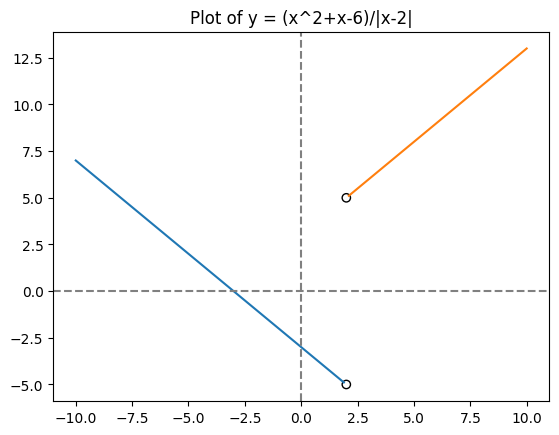

In [59]:
f = lambda x: (x**2 + x -6) / abs(x - 2)

x = np.linspace(-10, 1.89, 100)
y = [f(xi) for xi in x]
plt.plot(x, y)

x = np.linspace(2.11, 10, 100)
y = [f(xi) for xi in x]
plt.plot(x, y)

plt.scatter([2, 2], [5, -5], facecolors='none', edgecolors="black")

plt.axvline(0, linestyle="--", color="grey")
plt.axhline(0, linestyle="--", color="grey")
plt.title("Plot of y = (x^2+x-6)/|x-2|");

6) Consider the function $f(x) = \frac{1}{2 - x}(\frac{\sqrt{x + 2}}{\sqrt{x - 1}} - 2)$, does $\lim_{x \to 2} f(x)$ exist?

*Solution*: \
To begin, $f(2)$ is undefined. We can simplify $f(x)$ as follows:
$$
\begin{align}
f(x) &= \frac{1}{2 - x}(\frac{\sqrt{x + 2}}{\sqrt{x - 1}} - 2) \\
&= \frac{1}{2 - x}(\frac{\sqrt{x + 2} -2\sqrt{x - 1}}{\sqrt{x - 1}}) \\
&= \frac{1}{2 - x}(\frac{\sqrt{x + 2} -2\sqrt{x - 1}}{\sqrt{x - 1}})(\frac{\sqrt{x + 2} +2\sqrt{x - 1}}{\sqrt{x + 2} +2\sqrt{x - 1}}) \\
&= \frac{1}{2 - x}(\frac{-3x - 6}{\sqrt{x - 1}(\sqrt{x + 2} +2\sqrt{x - 1}}) \\
&= \frac{3(2 - x)}{2 - x}(\frac{1}{\sqrt{x - 1}(\sqrt{x + 2} + 2\sqrt{x - 1})} \\ 
&= \frac{3}{\sqrt{x - 1}(\sqrt{x + 2} + 2\sqrt{x - 1})} \\
\end{align}
$$
Now, from this we can see that $\lim_{x \to 2} f(x) = \frac{3}{4}$ since the function is now defined at $x = 2$. This limit is the same on both sides of $x = 2$ so the limit exists. 

7) Prove or disprove that $f(x) = \begin{cases} \frac{1}{x} - \frac{1}{\lvert x \rvert} , & \text{ if} x \neq0 \\ 0, & \text{if } x = 0 \end{cases}$ , is continuous at $x = 0$.

*Solution*: \
At $x = 0$ it is clear that $f(x) = 0$ so all that needs to be defined is that $\lim_{x \to 0^+} f(x) = \lim_{x \to 0^-} f(x) = 0$. For $x > 0$ we have that $f(x) = 0$ because $\lvert x \rvert$ will be the same as $x$ for all $x$. For $x < 0$ we have that $\lim_{x \to 0^-} f(x) = \frac{1}{0^-} - \frac{1}{0^+} = -\inf$. This means the limit does not exist, and the function is not continuous at $x = 0$.

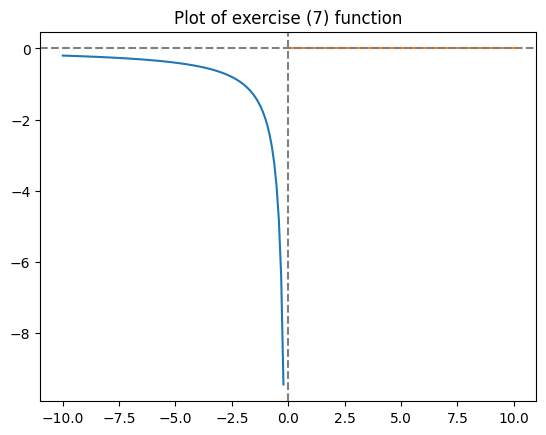

In [66]:
f = lambda x: (1/x) - (1/abs(x)) if x != 0 else 0

x = np.linspace(-10, -0.01, 100)
y = np.array([f(xi) for xi in x])
mask = [yi > -10 for yi in y]
x, y = x[mask], y[mask]
plt.plot(x, y)

x = np.linspace(0.01, 10, 100)
y = np.array([f(xi) for xi in x])
mask = [yi > -10 for yi in y]
x, y = x[mask], y[mask]
plt.plot(x, y)

plt.axvline(0, linestyle="--", color="grey")
plt.axhline(0, linestyle="--", color="grey")
plt.title("Plot of exercise (7) function"); 

8) Use the [squeeze theorem](https://www.khanacademy.org/math/ap-calculus-ab/ab-limits-new/ab-1-8/v/squeeze-sandwich-theorem) to show that $\lim_{t \to 0} t*\cos(1/t) = 0$.

*Solution*: \
First, note that the limit $\lim_{t \to 0} \cos(1/t)$ does not exist. As such we cannot put the limit inside the function and solve that way.

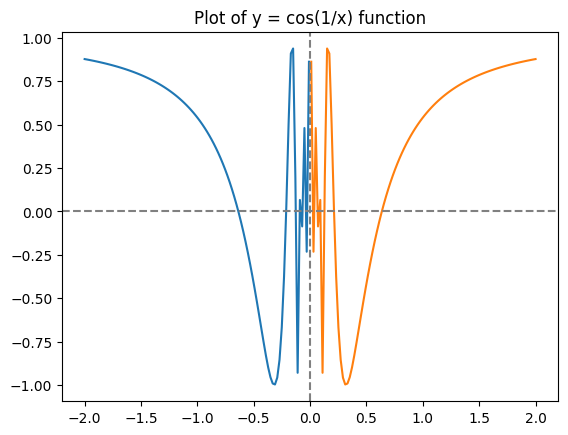

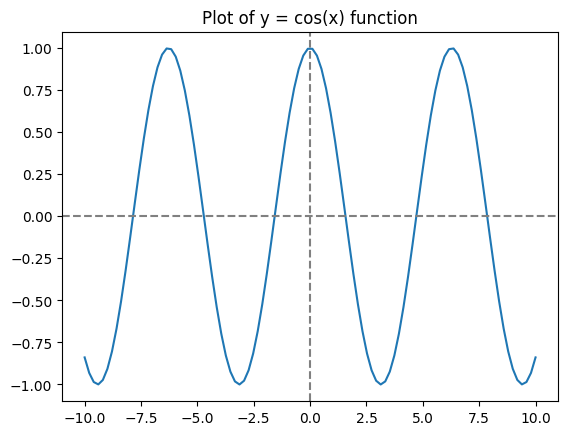

In [74]:
f = lambda x: math.cos(1/x)

x = np.linspace(-2, -0.01, 100)
y = [f(xi) for xi in x]
plt.plot(x, y)

x = np.linspace(0.01, 2, 100)
y = [f(xi) for xi in x]
plt.plot(x, y)

plt.axvline(0, linestyle="--", color="grey")
plt.axhline(0, linestyle="--", color="grey")
plt.title("Plot of y = cos(1/x) function")
plt.show()

x = np.linspace(-10, 10, 100)
y = [math.cos(xi) for xi in x]
plt.plot(x, y)
plt.axvline(0, linestyle="--", color="grey")
plt.axhline(0, linestyle="--", color="grey")
plt.title("Plot of y = cos(x) function");

We know that $-1 \leq \cos(x) \leq 1$ for all $x \in \mathbb{R}$, so $-1 \leq cos(1/t) \leq 1$ for every $t \in \mathbb{R}\setminus{\{0\}}$. Now for every $t \geq 0$ we have that $-t \leq t\cos(1/t) \leq t$ *(inequality 1)*. However, for $t \lt 0$, we would be changing the direction of the inequalities, so we have to be a bit careful. Tackling them seperately:

Left side: \
    $-1 \leq \cos(1/t)$ - Multiplying by $t \lt 0$\
    $-t \geq t*\cos(1/t)$

Right side: \
    $\cos(1/t) \leq 1$ - Multiplying by $t \lt 0$\
    $t*\cos(1/t) \geq t$

Putting them back together gives: $-t \geq t*\cos(1/t) \geq t$ for any $t \lt 0$ *(inequality 2)*. Using inequality 1, we can use the squeeze theorem to share that $\lim_{t \to 0^+} t*\cos(1/t)$ satisfies:
$$
\begin{align}
\lim_{t \to 0^+} -t \leq &\lim_{t \to 0^+} t*\cos(1/t) \leq \lim_{t \to 0^+} t \\
0 \leq &\lim_{t \to 0^+} t*\cos(1/t) \leq 0 
\end{align}
$$
So, $\lim_{t \to 0^+} t*\cos(1/t) = 0$. Using inequality 2, we can so the same process to find:
$$
\begin{align}
\lim_{t \to 0^-} -t \geq &\lim_{t \to 0^-} t*\cos(1/t) \geq \lim_{t \to 0^-} t \\
0 \geq &\lim_{t \to 0^-} t*\cos(1/t) \geq 0 
\end{align}
$$
So, $\lim_{t \to 0^-} t*\cos(1/t) = 0$. In conclusion, $\lim_{t \to 0^+} t*\cos(1/t) = \lim_{t \to 0^-} t*\cos(1/t) = 0$ and thus, $\lim_{t \to 0} t*\cos(1/t) = 0$. 

9) Compute the limit $\lim_{x \to 0} x^2*e^{\sin(\frac{1}{x})}$

*Solution*: \
Again, we will use the squeeze theorem.

To be continued!!! 